### Step 1: Install Required Libraries

In this step, the required libraries such as PyTorch, Torchvision, and Matplotlib are installed.
These libraries are essential for building and training the CycleGAN model, performing image
transformations, and visualizing the results.

- PyTorch: Deep learning framework used for model implementation
- Torchvision: Provides image preprocessing utilities
- Matplotlib: Used for displaying results

In [ ]:
!pip install torch torchvision matplotlib

### Step 2: Download and Extract Dataset

In this step, the EUVP (Enhancing Underwater Visual Perception) dataset is downloaded from Kaggle
and extracted into the working directory.

The dataset contains two domains:
- trainA: Underwater images
- trainB: Clear/enhanced images

These domains are used for unpaired image-to-image translation using CycleGAN.

In [ ]:
!kaggle datasets download -d pamuduranasinghe/euvp-dataset
!unzip euvp-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: EUVP/Unpaired/trainB/gmn_7677up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7678up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7679up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7680up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7681up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7682up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7683up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7684up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7685up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7686up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7687up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7688up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7689up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7690up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7691up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7692up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7693up.jpg  
  inflating: EUVP/Unpaired/trainB/gmn_7694up.jpg  
  inflating: EUVP/Unpaired/trai

### Step 3: Import Required Libraries

This step imports all necessary libraries for model development, data handling, and visualization.

- torch: Core deep learning library
- torch.nn: Neural network modules
- torch.optim: Optimization algorithms
- torchvision.transforms: Image preprocessing
- PIL: Image loading and processing
- matplotlib: Visualization of results

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

### Step 4: Define Custom Dataset Class

In this step, a custom dataset class 'UnderwaterDataset' is defined to load images from two domains.

Key features:
- Loads underwater images (Domain A) and clear images (Domain B)
- Converts images to RGB format
- Applies preprocessing transformations
- Returns unpaired image samples

CycleGAN works with unpaired data, so images from both domains are loaded independently.

In [ ]:
class UnderwaterDataset(Dataset):
    def __init__(self, pathA, pathB, transform=None):
        self.pathA = pathA
        self.pathB = pathB
        self.transform = transform

        self.filesA = os.listdir(pathA)
        self.filesB = os.listdir(pathB)

    def __len__(self):
        return min(len(self.filesA), len(self.filesB))

    def __getitem__(self, idx):
        imgA = Image.open(os.path.join(self.pathA, self.filesA[idx])).convert("RGB")
        imgB = Image.open(os.path.join(self.pathB, self.filesB[idx])).convert("RGB")

        if self.transform:
            imgA = self.transform(imgA)
            imgB = self.transform(imgB)

        return imgA, imgB

### Step 5: Image Preprocessing and Data Loading

This step defines preprocessing transformations and prepares the dataset for training.

Transformations applied:
- Resize images to 128x128
- Convert images to tensors
- Normalize pixel values to [-1, 1]

A DataLoader is used to:
- Load data in batches
- Shuffle data for better generalization
- Improve training efficiency

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))  # IMPORTANT
])

In [ ]:
dataset = UnderwaterDataset(
    "EUVP/Unpaired/trainA",
    "EUVP/Unpaired/trainB",
    transform
)

# dataset = torch.utils.data.Subset(dataset, range(200))  # optional

loader = DataLoader(dataset, batch_size=1, shuffle=True)

### Step 6: Generator Network Architecture

In this step, the Generator model is defined.

Architecture:
- Downsampling layers: Extract image features
- Middle layers: Transform features
- Upsampling layers: Reconstruct enhanced image

The generator learns to convert underwater images into enhanced images.

The final layer uses Tanh activation to ensure output values are in the range [-1, 1].

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,4,2,1),
            nn.ReLU()
        )

        self.middle = nn.Sequential(
            nn.Conv2d(128,128,3,1,1),
            nn.ReLU(),
            nn.Conv2d(128,128,3,1,1),
            nn.ReLU()
        )

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(128,64,3,1,1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(64,3,3,1,1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.down(x)
        x = self.middle(x)
        x = self.up(x)
        return x

### Step 7: Discriminator Network Architecture

This step defines the Discriminator model.

Purpose:
- Classifies images as real or fake
- Helps improve generator performance through adversarial training

Architecture:
- Convolution layers for feature extraction
- LeakyReLU activation for better gradient flow
- Sigmoid output for probability prediction

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128,1,4,1,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

### Step 8: Model Initialization

In this step, all CycleGAN components are initialized:

- Generator G: Converts underwater → enhanced
- Generator F: Converts enhanced → underwater
- Discriminator D_X and D_Y: Distinguish real vs fake images

The models are moved to the appropriate device (CPU or GPU).

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
F_model = Generator().to(device)
D_X = Discriminator().to(device)
D_Y = Discriminator().to(device)

### Step 9: Weight Initialization

This step initializes the weights of convolutional layers using a normal distribution.

Purpose:
- Improves training stability
- Prevents vanishing/exploding gradients
- Helps faster convergence

In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.normal_(m.weight, 0.0, 0.02)

G.apply(init_weights)
F_model.apply(init_weights)
D_X.apply(init_weights)
D_Y.apply(init_weights)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
    (4): Conv2d(128, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)

### Step 10: Loss Functions and Optimizers

In this step, loss functions and optimizers are defined.

Loss Functions:
- GAN Loss (MSE): Ensures realistic image generation
- Cycle Consistency Loss (L1): Ensures reconstruction of original image
- Identity Loss: Preserves color consistency

Optimizer:
- Adam optimizer is used to update model parameters efficiently

In [ ]:
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()

opt_G = optim.Adam(list(G.parameters()) + list(F_model.parameters()), lr=0.0001)
opt_D = optim.Adam(list(D_X.parameters()) + list(D_Y.parameters()), lr=0.0001)

### Step 11: Content and Perceptual Loss using VGG19

### ✔ What is done:
- Loaded pretrained VGG19 model (feature extractor)
- Used only feature layers (`features[:35]`)
- Disabled gradient updates for VGG parameters
- Defined:
  - Content Loss
  - Perceptual Loss

### ✔ Purpose:
This step introduces advanced loss functions that compare images in feature space
instead of pixel space, improving the quality of generated images.

### ✔ Key Logic:
- Content Loss: Measures similarity using L1 loss
- Perceptual Loss: Measures similarity using squared difference of feature maps

### ✔ Explanation:
The VGG19 model extracts high-level features such as edges, textures, and shapes.
Instead of comparing raw pixel values, the model compares these features to ensure
that the generated image looks visually similar to the target image.

### ✔ Key Benefit:
- Preserves structure and texture
- Improves visual realism
- Produces better enhancement results

### ✔ Note:
VGG19 is pretrained and used only as a feature extractor, so its weights are frozen.

In [ ]:
import torchvision.models as models
import torch.nn.functional as F

vgg = models.vgg19(pretrained=True).features[:35].to(device).eval()

for p in vgg.parameters():
    p.requires_grad = False

def content_loss(x, y):
    return F.l1_loss(vgg(x), vgg(y))

def perceptual_loss(x, y):
    return torch.mean((vgg(x) - vgg(y))**2)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 129MB/s] 


### Step 12: Gaussian Blur for Image Smoothing

### ✔ What is done:
- Defined Gaussian Blur using torchvision transforms
- Created helper function `get_blur(img)`

### ✔ Purpose:
This step applies a smoothing operation to images to reduce noise and improve
training stability.

### ✔ Key Logic:
- Applies Gaussian filter to input image
- Returns blurred version of image

### ✔ Explanation:
Gaussian blur reduces high-frequency noise and smooths the image. This helps the
model focus on important structures instead of fine noise patterns.

### ✔ Key Benefit:
- Reduces noise in images
- Improves stability of GAN training
- Helps discriminator learn better features

In [ ]:
import torchvision.transforms as T
blur = T.GaussianBlur(5)

def get_blur(img):
    return blur(img)

### Step 13: CycleGAN Training Process

This step implements the training loop.

Training involves:
1. Training the Discriminator:
   - Distinguishes real and fake images

2. Training the Generator:
   - Adversarial loss: Fool the discriminator
   - Cycle loss: Maintain image structure
   - Identity loss: Preserve color information

This iterative process helps the model learn mapping between underwater and enhanced domains.

In [ ]:
for epoch in range(10):
    for real_X, real_Y in loader:

        real_X = real_X.to(device)
        real_Y = real_Y.to(device)

        # Train Discriminator
        fake_Y = G(real_X).detach()

        loss_D_real = criterion_GAN(D_Y(real_Y), torch.ones_like(D_Y(real_Y)))
        loss_D_fake = criterion_GAN(D_Y(fake_Y), torch.zeros_like(D_Y(fake_Y)))

        loss_D = (loss_D_real + loss_D_fake) * 0.5

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        fake_Y = G(real_X)
        fake_X = F_model(real_Y)

        cycle_X = F_model(fake_Y)
        cycle_Y = G(fake_X)

        loss_GAN = criterion_GAN(D_Y(fake_Y), torch.ones_like(D_Y(fake_Y)))

        loss_cycle = (
            criterion_cycle(cycle_X, real_X) +
            criterion_cycle(cycle_Y, real_Y)
        )

        identity_Y = G(real_Y)
        identity_X = F_model(real_X)

        loss_identity = (
            criterion_cycle(identity_Y, real_Y) +
            criterion_cycle(identity_X, real_X)
        )

        loss_G = loss_GAN + loss_cycle + 0.5 * loss_identity

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch} completed")

Epoch 0 completed
Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed


### Step 14: Post-Processing Enhancement

In this step, a final enhancement function is defined to improve visual quality.

Techniques used:
- White balancing to correct color distortion
- CLAHE for contrast enhancement
- Blending to avoid over-enhancement

This step refines the output of the GAN model.

In [ ]:
import cv2
import numpy as np

def final_enhancement(img):
    img = (img * 255).astype(np.uint8)

    result = cv2.xphoto.createSimpleWB().balanceWhite(img)

    lab = cv2.cvtColor(result, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=1.0)
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    final = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    final = 0.7 * img + 0.3 * final

    return final / 255.0

### Step 13: Testing and Visualization

This step evaluates the trained model on sample images.

Process:
- Generate output using the generator
- Apply blending to stabilize results
- Apply final enhancement

Output includes:
- Original Image
- GAN Output
- Final Enhanced Image

This comparison helps in analyzing model performance.

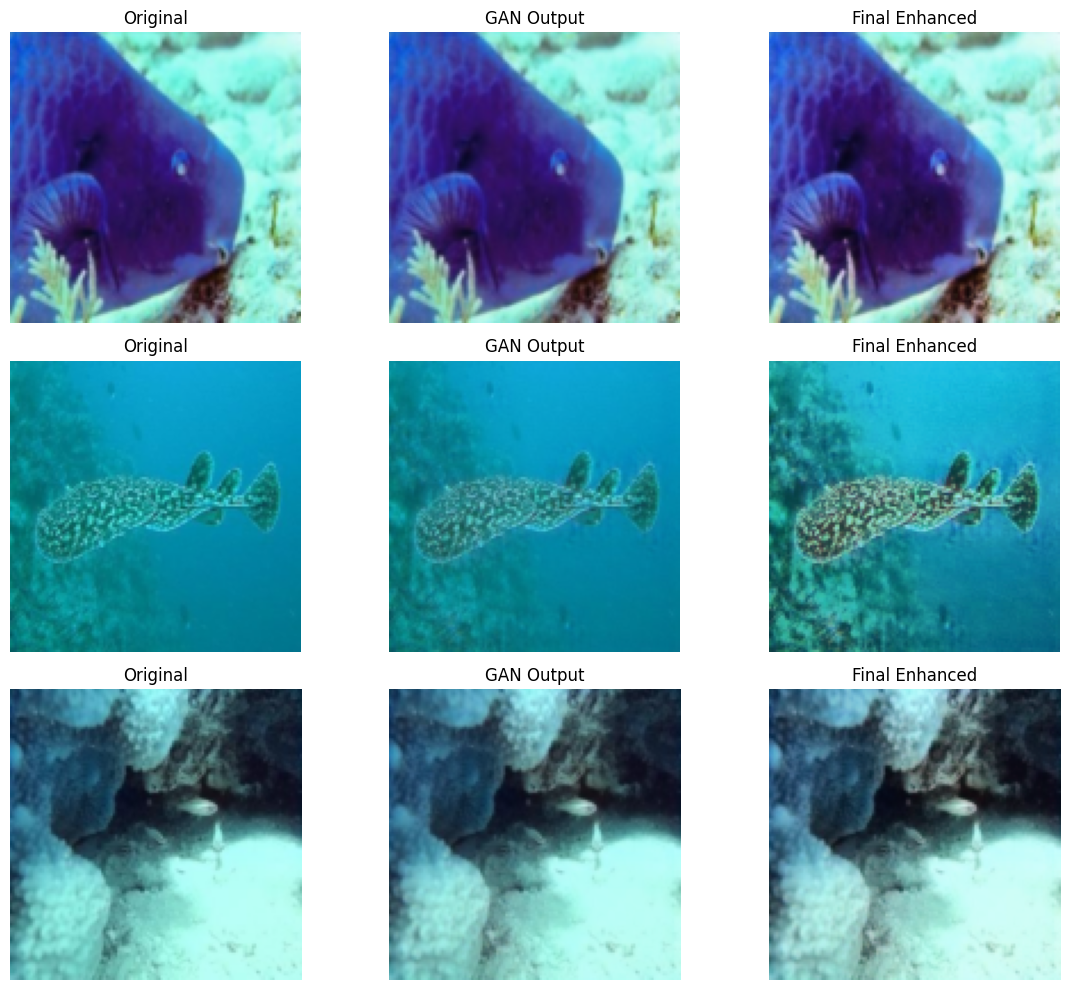

In [ ]:
plt.figure(figsize=(12,10))

indices = [0, 10, 50]

for i, idx in enumerate(indices):

    img, _ = dataset[idx]

    if img.dim() == 3:
        img = img.unsqueeze(0)

    img = img.to(device)

    with torch.no_grad():
        output = G(img)

    output = 0.85 * img + 0.15 * output

    input_img = img.squeeze().permute(1,2,0).cpu().detach().numpy()
    gan_img = output.squeeze().permute(1,2,0).cpu().detach().numpy()

    input_img = (input_img + 1) / 2
    gan_img = (gan_img + 1) / 2

    input_img = input_img.clip(0,1)
    gan_img = gan_img.clip(0,1)

    final_img = final_enhancement(gan_img)

    plt.subplot(len(indices), 3, 3*i+1)
    plt.imshow(input_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(len(indices), 3, 3*i+2)
    plt.imshow(gan_img)
    plt.title("GAN Output")
    plt.axis("off")

    plt.subplot(len(indices), 3, 3*i+3)
    plt.imshow(final_img)
    plt.title("Final Enhanced")
    plt.axis("off")

plt.tight_layout()
plt.show()